# Kalman–Koopman State Estimation under Partial Observations

In most training loops, `observation_masks` only gate losses. This notebook instead uses `KoopmanObserver` for **sensor-outage imputation**: reconstructing masked node features with a latent-space Kalman filter and Rauch–Tung–Striebel (RTS) smoother.

**Process model (library row convention).** Per-node latents evolve as

$$z_{t+1} = z_t K^\top + w_t,\qquad w_t\sim\mathcal{N}(0,\sigma^2 I),$$

with $z_t\in\mathbb{R}^{N\times d}$. Equivalently, in column form on each node, $s^+=Ks$. On the flattened state $x=\mathrm{vec}_{\mathrm{row}}(z)$, the filter uses $A=I_N\otimes K$ (independent nodes for a dense `KoopmanOperator`). With known $K$ and matched $Q=\sigma^2 I$, the Kalman *process* step is exact and linear—not an approximate linearization.

**Observation model (honest limits).**
- Default `observation_model="latent_encode"`: optionally warm-start (or zero) masked features, encode, then keep **selected** rows of $H=I_{Nd}$ for observed node blocks. Under masks this is a selection matrix $H_t=S_t$, not full $I$—**heuristic** and fast. This notebook zeros unobserved inputs (`graph_diffusion_warm_start=False`).
- `observation_model="decoder_jacobian"`: EKF-style $H=\partial\mathrm{decode}/\partial z$ with **unobserved feature rows dropped**. This follows the decoder-Jacobian observation model, but is costly and only locally valid for nonlinear GNN decoders.

Here encode/decode are identity maps, so observed measurements are the true latent coordinates (the plant has no sensor noise). Observer $R$ is a small tuning covariance, not a matched measurement model.

**Related work** (not identical algorithms): Koopman-based observer synthesis for control-affine input–output systems [@Surana2016]; Kalman-refined latent dynamics in $K^2$VAE [@Wu2025K2VAE].

> **Primary question.** On a noisy synthetic linear plant (identity encode/decode), with a fully observed burn-in and **nested** dropout masks: does masked-node imputation RMSE rise with `drop_fraction`? Does RTS smoothing beat causal filtering? Do both beat hold-last and zero-fill?


In [1]:
import warnings
from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data

from koopman_graph import (
    GNNDecoder,
    GNNEncoder,
    GraphKoopmanModel,
    GraphSnapshotSequence,
)
from koopman_graph.adaptation import KoopmanObserver

CI = bool(os.environ.get("PYTEST_CURRENT_TEST"))
STEPS = 24 if CI else 60
BURN_IN = 4 if CI else 8
DROPS = [0.1, 0.3, 0.5] if CI else [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
PROCESS_STD = 0.05
OBS_NOISE = 1e-3
_ = torch.manual_seed(0)


## Synthetic noisy linear plant

Node features equal latents; `K` is diagonal and known. Isotropic process noise keeps imputation nontrivial after burn-in. Encode/decode are patched to identity so `latent_encode` matches a textbook latent Kalman filter on observed node blocks.

Plant step (matches `KoopmanOperator` and observer flattening):

```text
z ← z @ K.T + process_std * ε,   ε ~ N(0, I)
```

**Protocol (avoids cold-start artifacts):**
1. Fully observe the first `BURN_IN` steps so the filter can lock on.
2. Draw one shared `U ~ Unif[0, 1]` field; mark missing when `U < drop_fraction` (nested masks).
3. Score masked-node RMSE only for `t ≥ BURN_IN`.

**Note.** Keeping node 0 always observed does **not** inform other nodes here: dense `K` yields independent per-node latents (`A = I ⊗ K`), so graph topology is unused by the process model.


In [2]:
def identity_encode(model, x_or_data, edge_index=None, edge_weight=None):
    _ = model, edge_index, edge_weight
    return x_or_data.x if isinstance(x_or_data, Data) else x_or_data


def build_plant(
    latent_dim=3,
    num_nodes=4,
    steps=STEPS,
    process_std=PROCESS_STD,
    seed=0,
):
    torch.manual_seed(seed)
    true_k = torch.diag(torch.linspace(0.92, 0.75, latent_dim))
    edge_index = torch.tensor(
        [list(range(num_nodes)), [(i + 1) % num_nodes for i in range(num_nodes)]],
        dtype=torch.long,
    )
    z = torch.randn(num_nodes, latent_dim)
    snaps, latents = [], []
    for _ in range(steps):
        snaps.append(Data(x=z.clone(), edge_index=edge_index))
        latents.append(z.clone())
        z = z @ true_k.T + process_std * torch.randn_like(z)
    seq = GraphSnapshotSequence(snaps)
    encoder = GNNEncoder(latent_dim, 8, latent_dim, num_layers=1)
    decoder = GNNDecoder(latent_dim, 8, latent_dim, num_layers=1)
    model = GraphKoopmanModel(
        encoder=encoder,
        decoder=decoder,
        latent_dim=latent_dim,
        time_step=1.0,
        koopman_parameterization="dense",
    )
    model.koopman.set_dense_matrix(true_k)
    model.encode = lambda *a, **k: identity_encode(model, *a, **k)
    model.decoder.forward = lambda z, edge_index, edge_weight=None: z
    return model, seq, torch.stack(latents), true_k


model, full_seq, true_z, true_k = build_plant()
print("K diag:", [round(v, 4) for v in true_k.diag().tolist()])
print(f"steps={STEPS}, burn_in={BURN_IN}, process_std={PROCESS_STD}")


K diag: [0.92, 0.835, 0.75]
steps=60, burn_in=8, process_std=0.05


## Nested dropout masks and baselines

**Baselines.** Hold-last carries each node's most recent observation forward; zero-fill replaces missing entries with zeros.

**Noise settings.** The Kalman filter and RTS smoother use matched process noise `Q = process_std² · I` on the flattened latent. Observation noise `R = OBS_NOISE · I` is a small regularizer on the **selected** measurement rows (under identity encode, plant sensors are noiseless).

**Scoring.** `impute` keeps observed features and fills only masked nodes from `decode(z)`. Masked-node RMSE is therefore an *imputation* score, not full-state filter MSE—the next section reports latent RMSE separately.


In [3]:
def nested_masks(num_timesteps, num_nodes, drop_fraction, *, burn_in, seed=0):
    """Build nested miss masks from a shared Uniform[0, 1] field."""
    torch.manual_seed(seed)
    uniforms = torch.rand(num_timesteps, num_nodes)
    masks = uniforms >= drop_fraction
    masks[:burn_in] = True
    masks[:, 0] = True  # one always-on sensor (does not couple independent latents)
    return masks


def masked_sequence(seq, drop_fraction, *, burn_in=BURN_IN, seed=0):
    masks = nested_masks(
        len(seq),
        seq.num_nodes,
        drop_fraction,
        burn_in=burn_in,
        seed=seed,
    )
    return GraphSnapshotSequence(list(seq), observation_masks=masks)


def masked_node_rmse(pred_x_by_t, truth, masks, *, burn_in=BURN_IN):
    errs = []
    for t in range(burn_in, len(truth)):
        miss = ~masks[t]
        if not bool(miss.any()):
            continue
        errs.append(torch.mean((pred_x_by_t[t][miss] - truth[t][miss]) ** 2).sqrt())
    if not errs:
        return float("nan")
    return float(torch.stack(errs).mean().item())


def hold_last_fill(seq, masks):
    """Per-node hold-last fill (observed values unchanged)."""
    filled = []
    last = seq[0].x.clone()
    for t, snap in enumerate(seq):
        x = snap.x.clone()
        for n in range(seq.num_nodes):
            if masks[t, n]:
                last[n] = x[n]
            else:
                x[n] = last[n]
        filled.append(x)
    return filled


def zero_fill(seq, masks):
    filled = []
    for t, snap in enumerate(seq):
        x = snap.x.clone()
        x[~masks[t]] = 0.0
        filled.append(x)
    return filled


observer = KoopmanObserver(
    model,
    process_noise=PROCESS_STD**2,
    observation_noise=OBS_NOISE,
    observation_model="latent_encode",
)

rows = []
for drop in DROPS:
    masked = masked_sequence(full_seq, drop)
    masks = masked.observation_masks
    assert masks is not None
    filt_seq = observer.impute(masked, use_smoother=False)
    smth_seq = observer.impute(masked, use_smoother=True)
    hold = hold_last_fill(full_seq, masks)
    zeros = zero_fill(full_seq, masks)
    row = {
        "drop": drop,
        "filter": masked_node_rmse([s.x for s in filt_seq], true_z, masks),
        "smooth": masked_node_rmse([s.x for s in smth_seq], true_z, masks),
        "hold_last": masked_node_rmse(hold, true_z, masks),
        "zero_fill": masked_node_rmse(zeros, true_z, masks),
    }
    rows.append(row)

print("drop  filter  smooth  hold_last  zero_fill")
for row in rows:
    print(
        f"{row['drop']:.1f}  {row['filter']:.4f}  {row['smooth']:.4f}  "
        f"{row['hold_last']:.4f}  {row['zero_fill']:.4f}"
    )

filter_rmses = [r["filter"] for r in rows]
smooth_rmses = [r["smooth"] for r in rows]
hold_rmses = [r["hold_last"] for r in rows]
zero_rmses = [r["zero_fill"] for r in rows]

# Soft checks aligned with the narrative (nested masks + burn-in).
# Strict per-step monotonicity is noisy; require end >= start and ranking.
assert smooth_rmses[-1] + 1e-5 >= smooth_rmses[0]
assert filter_rmses[-1] + 1e-5 >= filter_rmses[0]
assert all(s <= f + 1e-5 for s, f in zip(smooth_rmses, filter_rmses))
assert smooth_rmses[-1] < hold_rmses[-1]
assert filter_rmses[-1] < hold_rmses[-1]
assert smooth_rmses[-1] < zero_rmses[-1]


drop  filter  smooth  hold_last  zero_fill
0.1  0.0468  0.0394  0.0504  0.1051
0.2  0.0469  0.0367  0.0478  0.0949
0.3  0.0553  0.0419  0.0583  0.0974
0.4  0.0569  0.0437  0.0616  0.1021
0.5  0.0569  0.0483  0.0620  0.0990
0.6  0.0578  0.0510  0.0632  0.0983


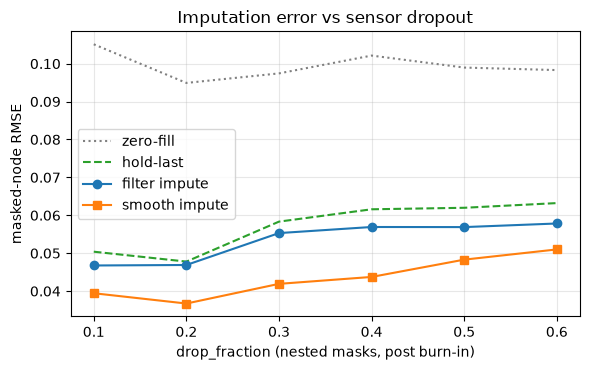

In [4]:
fig, ax = plt.subplots(figsize=(6.0, 3.8))
ax.plot(DROPS, zero_rmses, ":", color="0.5", label="zero-fill")
ax.plot(DROPS, hold_rmses, "--", color="C2", label="hold-last")
ax.plot(DROPS, filter_rmses, "o-", color="C0", label="filter impute")
ax.plot(DROPS, smooth_rmses, "s-", color="C1", label="smooth impute")
ax.set_xlabel("drop_fraction (nested masks, post burn-in)")
ax.set_ylabel("masked-node RMSE")
ax.set_title("Imputation error vs sensor dropout")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Filter vs smooth at fixed dropout

Complementary to masked-node imputation RMSE: fix one nested mask (`drop_fraction=0.4`) and compare **full latent** RMSE after burn-in (all nodes, not only masked entries). RTS smoothing should improve on causal filtering when future observations are available.


In [5]:
masked = masked_sequence(full_seq, drop_fraction=0.4)
filt = observer.filter(masked)
smth = observer.smooth(masked)
filt_err = torch.mean((filt.latents[BURN_IN:] - true_z[BURN_IN:]) ** 2).sqrt().item()
smth_err = torch.mean((smth.latents[BURN_IN:] - true_z[BURN_IN:]) ** 2).sqrt().item()
print(f"filter latent RMSE (t≥{BURN_IN}): {filt_err:.4f}")
print(f"smooth latent RMSE (t≥{BURN_IN}): {smth_err:.4f}")
assert smth_err <= filt_err + 1e-5

# Identity decode ⇒ local H ≈ I before row selection (keep the quick demo light).
jac_observer = KoopmanObserver(
    model,
    process_noise=PROCESS_STD**2,
    observation_noise=OBS_NOISE,
    observation_model="decoder_jacobian",
)
jac = jac_observer.filter(masked_sequence(full_seq, 0.3))
assert torch.isfinite(jac.latents).all()
print("decoder_jacobian filter OK", tuple(jac.latents.shape))


filter latent RMSE (t≥8): 0.0353
smooth latent RMSE (t≥8): 0.0282
decoder_jacobian filter OK (60, 4, 3)


## Takeaways

1. For fixed dense `K`, the latent **process** model is exactly linear (`z ← z Kᵀ + w` / `A = I ⊗ K`). Observation handling remains encode-heuristic (`H_t = S_t`) or EKF-local (`∂decode/∂z`)—not an exact Kalman filter in feature space for nonlinear decoders.
2. With nested masks, process noise, and a fully observed burn-in, masked-node RMSE **rises overall** with `drop_fraction` (end ≥ start; small local dips can occur from finite nested-mask samples).
3. RTS smoothing improves on causal filtering; both beat hold-last and zero-fill at high dropout.
4. Prefer `latent_encode` for large graphs and notebooks; use `decoder_jacobian` when you need the decoder-Jacobian observation model and can afford the Jacobian cost.
